In [51]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder 
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df=pd.read_csv("C:\\Users\\varsh\\Downloads\\Project_mrecw\\Project1\\HR Employee Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


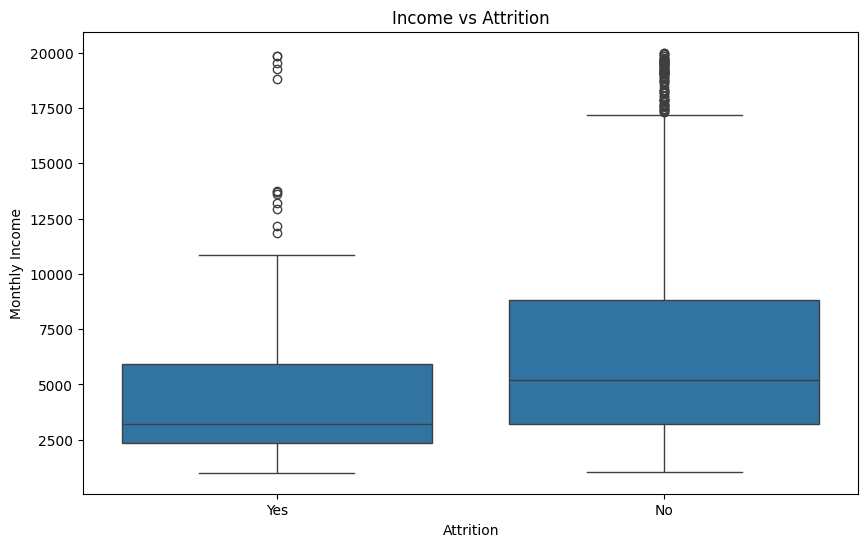

In [53]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition" ,y="MonthlyIncome" ,data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

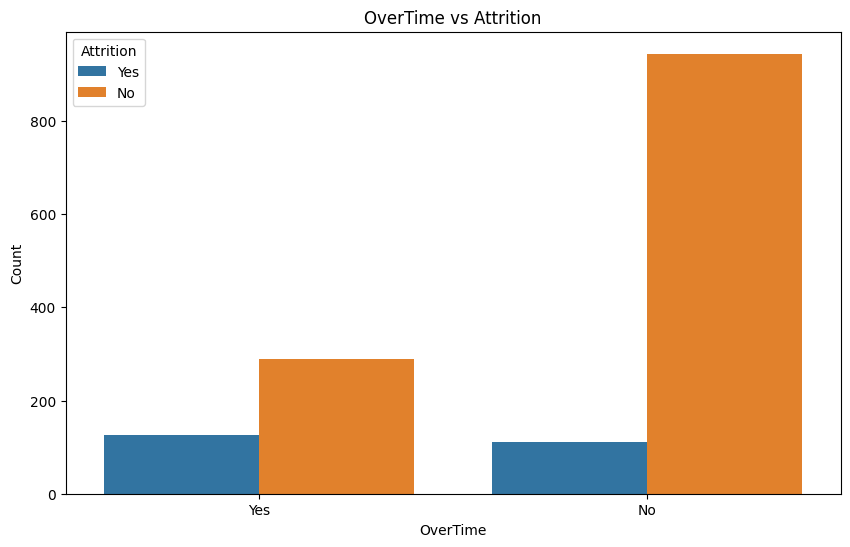

In [54]:
plt.figure(figsize=(10,6))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

In [ ]:
df.drop(["EmployeeNumber","EmployeeCount","Over18","StandardHours"],axis=1,inplace=True)
#df.info()
encoder={}
for col in df.select_dtypes(include="object").columns:
    lb=LabelEncoder()
    df[col]=lb.fit_transform(df[col])
    encoder[col]=lb
X=df.drop("Attrition",axis=1)
y=df["Attrition"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)

In [56]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
print("Best Hyperparameter:", grid_search.best_params_)

ValueError: 
All the 120 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\varsh\Downloads\Project_mrecw\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\varsh\Downloads\Project_mrecw\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\varsh\Downloads\Project_mrecw\.venv\Lib\site-packages\sklearn\ensemble\_forest.py", line 359, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        ensure_all_finite=F

              precision    recall  f1-score   support

          No       0.88      0.99      0.93       507
         Yes       0.75      0.15      0.25        81

    accuracy                           0.88       588
   macro avg       0.81      0.57      0.59       588
weighted avg       0.86      0.88      0.84       588

[[503   4]
 [ 69  12]]


Text(0, 0.5, 'Feature')

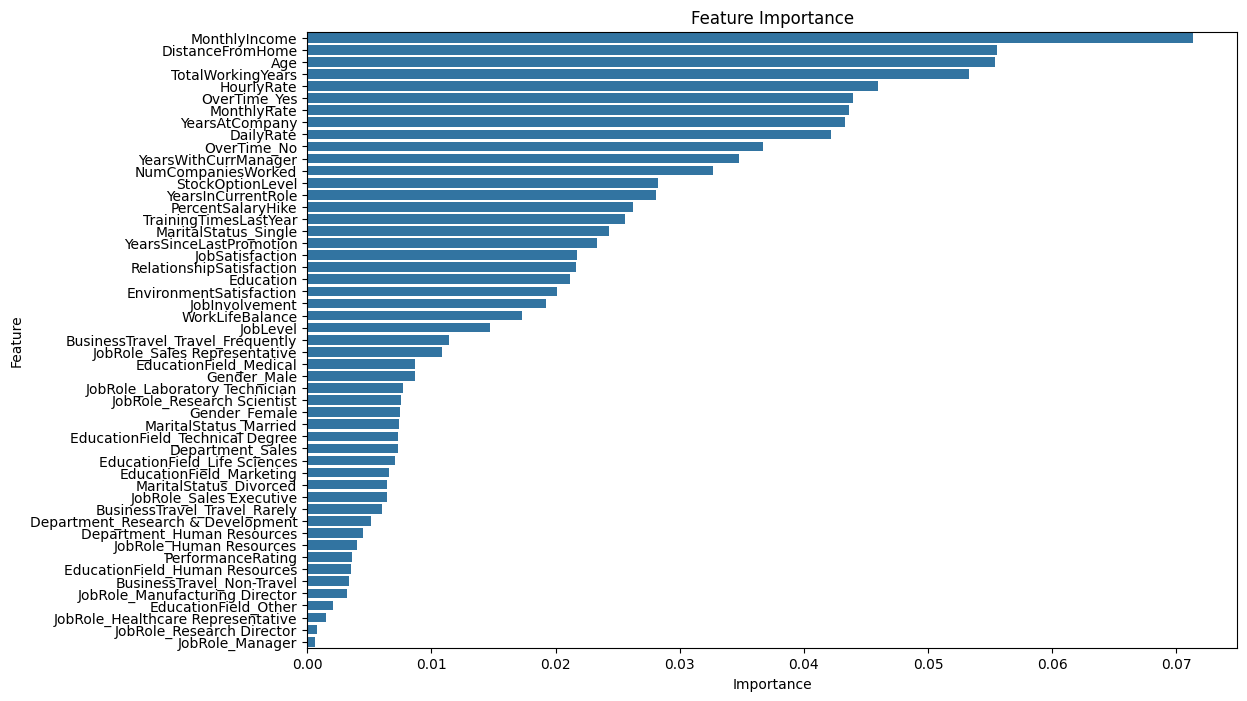

In [ ]:
best_model=grid_search.best_estimator_
predictions=best_model.predict(X_test)
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))
importances=best_model.feature_importances_
feature_importance_df=pd.DataFrame({
    "Feature":X.columns,
    "Importance":importances
}).sort_values(by="Importance",ascending=False)
plt.figure(figsize=(12,8))
sns.barplot(x="Importance",y="Feature",data=feature_importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

In [ ]:
model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model.fit(X, y)

joblib.dump(model, "employee_attrition_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")

['feature_columns.pkl']